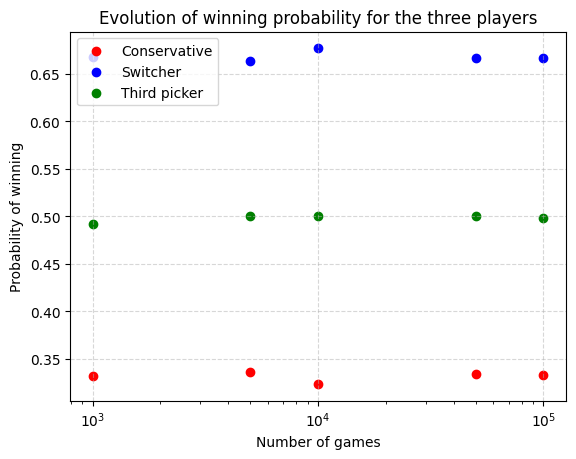

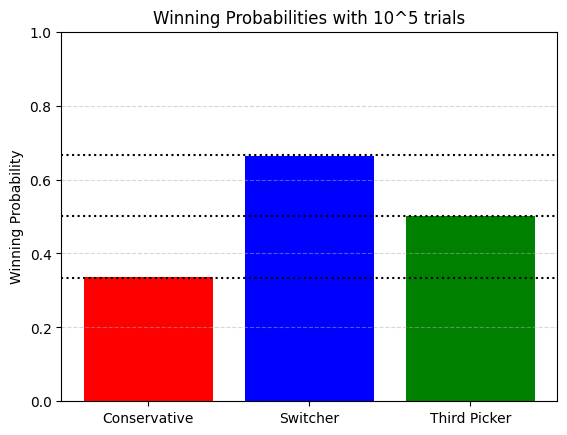

In [2]:
import numpy as np
import random
from matplotlib import pyplot as plt
def choice(a, b):
    
    x = random.randint(a,b)
    return x

stay_wins= 0
switch_win = 0
pick3_win = 0
cons_prob_arr = []
switch_prob_arr = []
pick3_prob_arr = []
N =[1000, 5000, 10000, 50000, 10**5]
def simulate_monty_hall(n_trials):
    stay_win= 0
    switch_win = 0
    pick3_win = 0
  
    for i in range(n_trials):
        doors = [0, 0, 1]  # One car, two goats
        random.shuffle(doors)
        pick = choice(0,2)
      
        # Host reveals a goat door that is not the pick
        reveal = next(j for j in range(3) if j != pick and doors[j] == 0)
       
    
        # If we stay
        if doors[pick] == 1:
            stay_win += 1
            
        # If we switch
        switch = next(j for j in range(3) if j != pick and j != reveal)

        #A third player choose between the two remaining doors
        remaining = [j for j in range(3) if j != reveal] #a list of the doors not revealed
        pick_3 = random.choice(remaining)
       
    

        if doors[switch] == 1:
           switch_win = switch_win+1
            
        if doors[pick_3] == 1:
           pick3_win = pick3_win+1

    stay_prob = (stay_win/n_trials)
    switch_prob = (switch_win/n_trials)
    pick3_prob = (pick3_win/n_trials)
    return [stay_prob, switch_prob, pick3_prob]
                  
for trials in N:
    probs = simulate_monty_hall(trials)
    cons_prob_arr.append(probs[0])
    switch_prob_arr.append(probs[1])
    pick3_prob_arr.append(probs[2])

# Probability evolution
plt.scatter(N, cons_prob_arr, color='red', label='Conservative')
plt.scatter(N, switch_prob_arr, color='blue', label='Switcher')
plt.scatter(N, pick3_prob_arr, color='green', label='Third picker')
plt.legend()
plt.xlabel('Number of games')
plt.ylabel('Probability of winning')
plt.title('Evolution of winning probability for the three players')
plt.xscale('log')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Bar chart for N = 10**5
probs_10e5 = simulate_monty_hall(10**5)

players = ['Conservative', 'Switcher', 'Third Picker']
colors = ['red', 'blue', 'green']

plt.bar(players, probs_10e5, color=colors)
plt.ylim(0, 1)
plt.ylabel('Winning Probability')
for y in [1/3,1/2,2/3]:
    plt.axhline(y, ls='dotted',c='black')
plt.title('Winning Probabilities with 10^5 trials')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [7]:
from random import sample

stay_wins= 0
switch_win = 0
pick3_win = 0
cons_prob_arr = []
switch_prob_arr = []
pick3_prob_arr = []

def simulate_monty_hall_general(n, p, n_trials = 10000):
    stay_win= 0
    switch_win = 0
    pick3_win = 0
  
    for i in range(n_trials):
        doors = [0]* n  #  Initialize N doors
        car_pos = choice(0, n-1)
        doors[car_pos] = 1
        pick = choice(0,n-1)
      

        avaible_open = [j for j in range(n) if j != pick and doors[j] == 0]
        reveal = sample(avaible_open, p) #The host reveal p doors with goats behind
       
    
        # If we stay
        if doors[pick] == 1:
            stay_win += 1

        #Consider only doors take are not revealed or chosen at the beginning
        remaining = [j for j in range(n) if j not in reveal and j != pick]
        
        # If we switch
      
        switch = random.choice(remaining)
    
        #A third player choose between the remaining doors
        remaining = [j for j in range(n) if j not in reveal and j != pick]  #a list of the doors not revealed
        pick_3 = random.choice(remaining)
       
    

        if doors[switch] == 1:
           switch_win = switch_win+1
            
        if doors[pick_3] == 1:
           pick3_win = pick3_win+1

    stay_prob = (stay_win/n_trials)
    switch_prob = (switch_win/n_trials)
    pick3_prob = (pick3_win/n_trials)
    return [stay_prob, switch_prob, pick3_prob]
n_doors = 1000
p_rev = np.arange(1, 1001, 100)

exp_prob_sw = []
exp_prob_st = []
exp_prob_3 = []
for p in p_rev:
    probs = simulate_monty_hall_general( n_doors, p)
    cons_prob_arr.append(probs[0])
    switch_prob_arr.append(probs[1])
    pick3_prob_arr.append(probs[2])
        
    exp_prob_sw.append(1/n_doors *(n_doors-1)/(n_doors-p-1))
    exp_prob_st.append(1/n_doors)
    exp_prob_3.append(1/(n_doors-p))

    

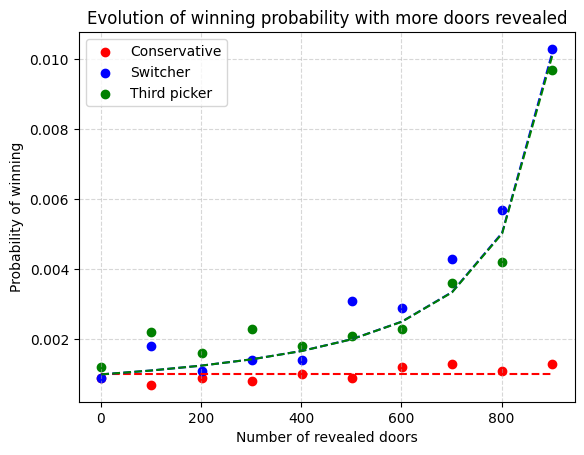

In [8]:
# Probability evolution with an increasing number of doors revealed
plt.scatter(p_rev, cons_prob_arr, color='red', label='Conservative')
plt.scatter(p_rev, switch_prob_arr, color='blue', label='Switcher')
plt.scatter(p_rev, pick3_prob_arr, color='green', label='Third picker')
plt.legend()
plt.xlabel('Number of revealed doors')
plt.ylabel('Probability of winning')
plt.title('Evolution of winning probability with more doors revealed')
plt.plot(p_rev, exp_prob_st, color = 'red', linestyle = '--', label = 'Expected - Conservative')
plt.plot(p_rev, exp_prob_sw, color = 'blue', linestyle = '--', label = 'Expected - Switcher')
plt.plot(p_rev, exp_prob_3, color = 'green', linestyle = '--', label = 'Expected - Third Picker')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()